In [94]:
# !pip install --upgrade sympy

In [95]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.interpolate import griddata
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
print(np.__version__)
print(pd.__version__)

1.26.4
2.3.2


In [96]:
df = pd.read_csv('JUIndoorLoc-Training-data.csv')
df_test = pd.read_csv('JUIndoorLoc-Test-data.csv')
df.shape, df_test.shape

((23904, 177), (1460, 177))

In [97]:
split_cols = df['Cid'].str.lstrip('L').str.split('-', expand=True)
split_cols.head(3)

,0,1,2
0,4,40,1
1,4,40,1
2,4,40,1


In [98]:
# Step 2: Assign new columns
df['floor'] = split_cols[0].astype(int)  # floor as integer
df['X'] = split_cols[1].astype(int)      # X coordinate
df['Y'] = split_cols[2].astype(int)      # Y coordinate

In [99]:
split_cols = df_test['Cid'].str.lstrip('L').str.split('-', expand=True)

# Step 2: Assign new columns
df_test['floor'] = split_cols[0].astype(int)  # floor as integer
df_test['X'] = split_cols[1].astype(int)      # X coordinate
df_test['Y'] = split_cols[2].astype(int)      # Y coordinate

In [100]:
df['floor'].value_counts()

floor
4    18016
5     4300
3     1588
Name: count, dtype: int64

In [101]:
df_test['floor'].value_counts()

floor
4    1460
Name: count, dtype: int64

In [102]:
df_3rd_floor = df[df['floor'] == 3]
df_4th_floor = df[df['floor'] == 4]
df_5th_floor = df[df['floor'] == 5]

In [103]:
def plot_floor_data(floor_df, label):
    fig, ax = plt.subplots()
    ax.scatter(floor_df['X'], floor_df['Y'])
    ax.set_xlabel('X(m)')
    ax.set_ylabel('Y(m)')
    ax.set_title(label)
    plt.show()

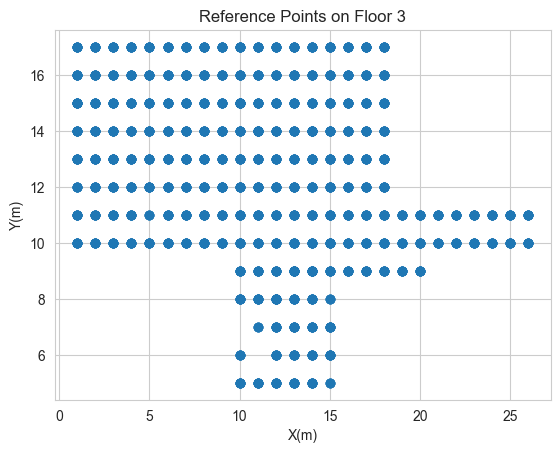

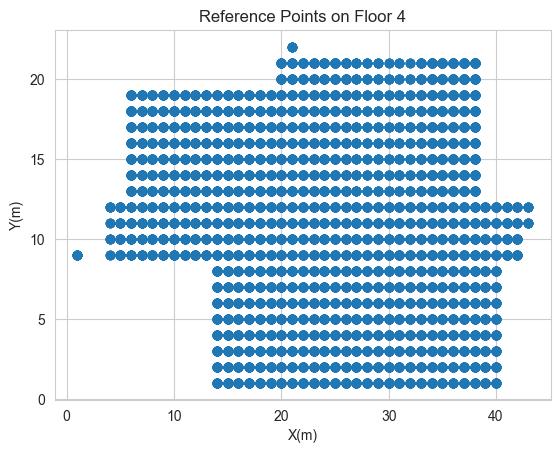

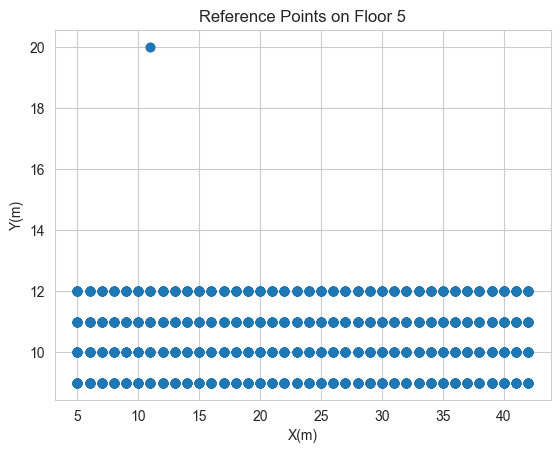

In [104]:
plot_floor_data(df_3rd_floor, "Reference Points on Floor 3")
plot_floor_data(df_4th_floor, "Reference Points on Floor 4")
plot_floor_data(df_5th_floor, "Reference Points on Floor 5")

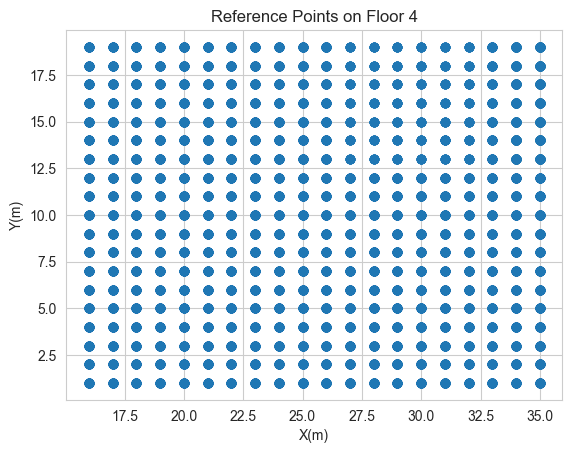

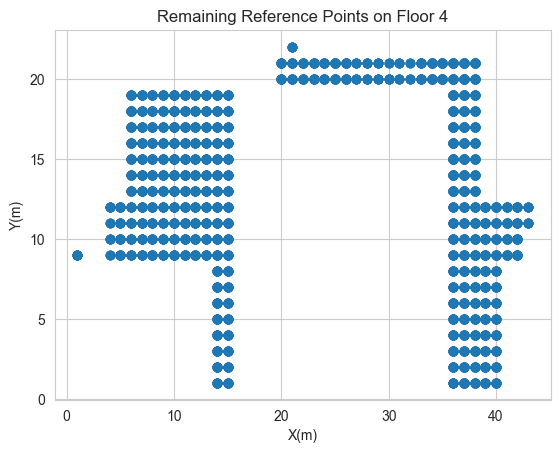

In [105]:
square_df = df_4th_floor[
    (df_4th_floor['X'] >= 16) & (df_4th_floor['X'] <= 35) & (df_4th_floor['Y'] >= 0) & (df_4th_floor['Y'] <= 19)]
remaining_df = df_4th_floor[
    ~((df_4th_floor['X'] >= 16) & (df_4th_floor['X'] <= 35) & (df_4th_floor['Y'] >= 0) & (df_4th_floor['Y'] <= 19))]
plot_floor_data(square_df, "Reference Points on Floor 4")
plot_floor_data(remaining_df, "Remaining Reference Points on Floor 4")


In [106]:
square_df.head(3)

,Cid,AP001,AP002,AP003,AP004,AP005,AP006,AP007,AP008,AP009,...,AP170,AP171,AP172,Rs,Hpr,Did,Ts,floor,X,Y
256,L4-34-1,-80,-81,-70,-63,-85,-75,-69,-110,-110,...,-110,-110,-110,0,0,D4,1469963153060,4,34,1
257,L4-34-1,-80,-81,-70,-63,-85,-75,-69,-110,-110,...,-110,-110,-110,0,0,D4,1470139819109,4,34,1
258,L4-34-1,-80,-80,-70,-63,-85,-75,-69,-110,-110,...,-110,-110,-110,0,0,D4,1469962304939,4,34,1


## Null values analysis:

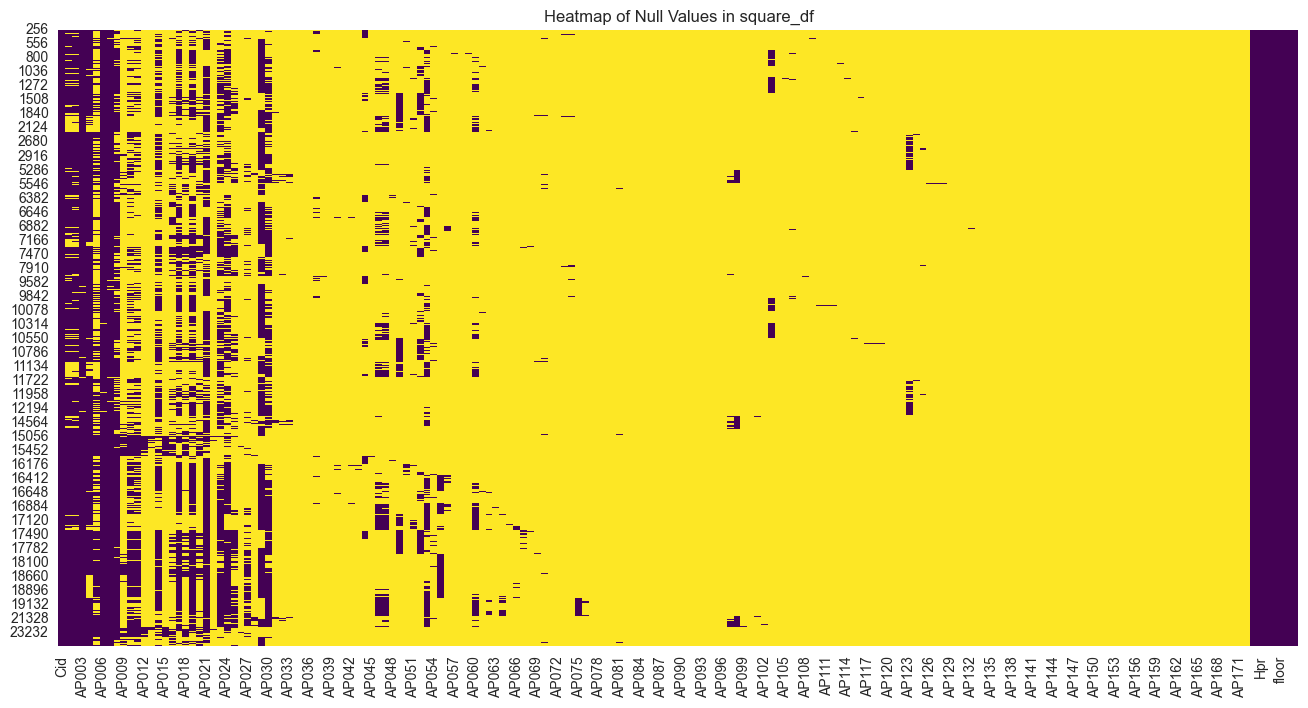

In [107]:
square_df = square_df.replace(-110, np.nan)
plt.figure(figsize=(16, 8))
sns.heatmap(square_df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Null Values in square_df')
plt.show()

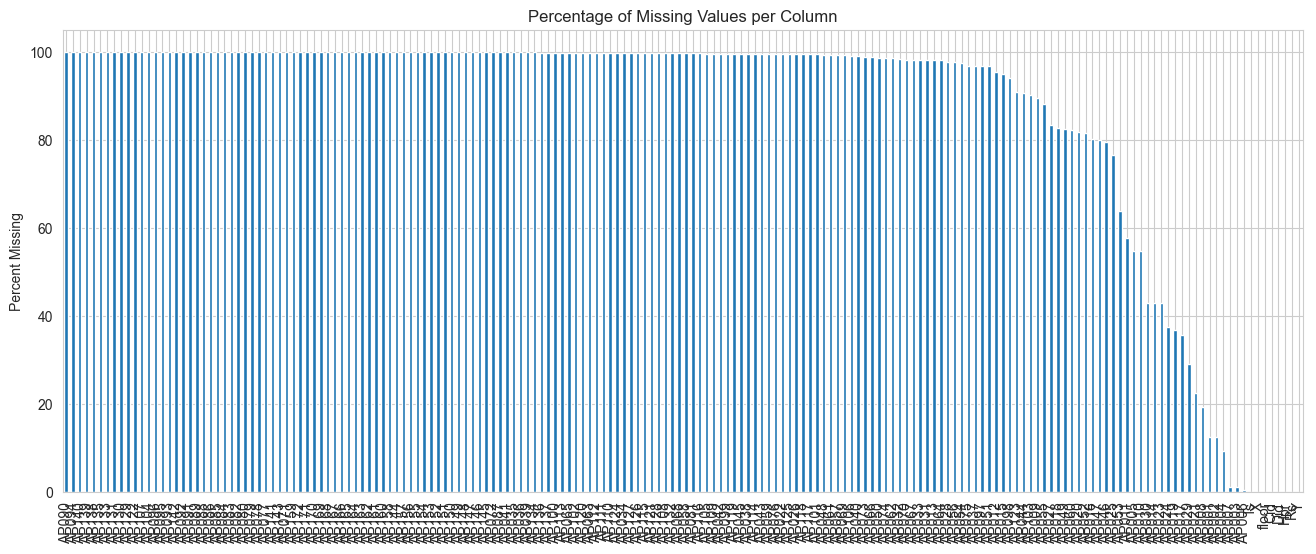

In [108]:
(square_df.isna().sum().sort_values(ascending=False) / len(square_df) * 100).plot(kind='bar', figsize=(16, 6), ylabel='Percent Missing')
plt.title('Percentage of Missing Values per Column')
plt.show()

In [109]:
print(f"Initial shape of the Dataset: {square_df.shape}")

Initial shape of the Dataset: (10379, 180)


In [110]:
null_percent = square_df.isna().sum() / len(square_df) * 100
cols_to_drop = null_percent[null_percent > 60].index
square_df_cleaned = square_df.drop(columns=cols_to_drop)
print(square_df_cleaned.info())

#-------------

null_percent_remaining_df = remaining_df.isna().sum() / len(remaining_df) * 100
cols_to_drop_remaining_df = null_percent_remaining_df[null_percent_remaining_df > 80].index
remaining_df_cleaned = remaining_df.drop(columns=cols_to_drop_remaining_df)
print(remaining_df_cleaned.info())

<class 'pandas.core.frame.DataFrame'>
Index: 10379 entries, 256 to 23847
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Cid     10379 non-null  object 
 1   AP001   9065 non-null   float64
 2   AP002   9069 non-null   float64
 3   AP003   10263 non-null  float64
 4   AP004   9391 non-null   float64
 5   AP005   4690 non-null   float64
 6   AP006   10331 non-null  float64
 7   AP007   10257 non-null  float64
 8   AP008   8357 non-null   float64
 9   AP010   4696 non-null   float64
 10  AP011   4383 non-null   float64
 11  AP014   5904 non-null   float64
 12  AP017   6675 non-null   float64
 13  AP019   6559 non-null   float64
 14  AP021   8028 non-null   float64
 15  AP023   5909 non-null   float64
 16  AP024   6486 non-null   float64
 17  AP029   7359 non-null   float64
 18  AP030   5903 non-null   float64
 19  Rs      10379 non-null  int64  
 20  Hpr     10379 non-null  int64  
 21  Did     10379 non-null  object 
 22  T

In [111]:
print(f"Dataset after dropping columns: {square_df_cleaned.shape}")
print(f"Remaining dataset after dropping columns: {remaining_df_cleaned.shape}")

Dataset after dropping columns: (10379, 26)
Remaining dataset after dropping columns: (7637, 180)


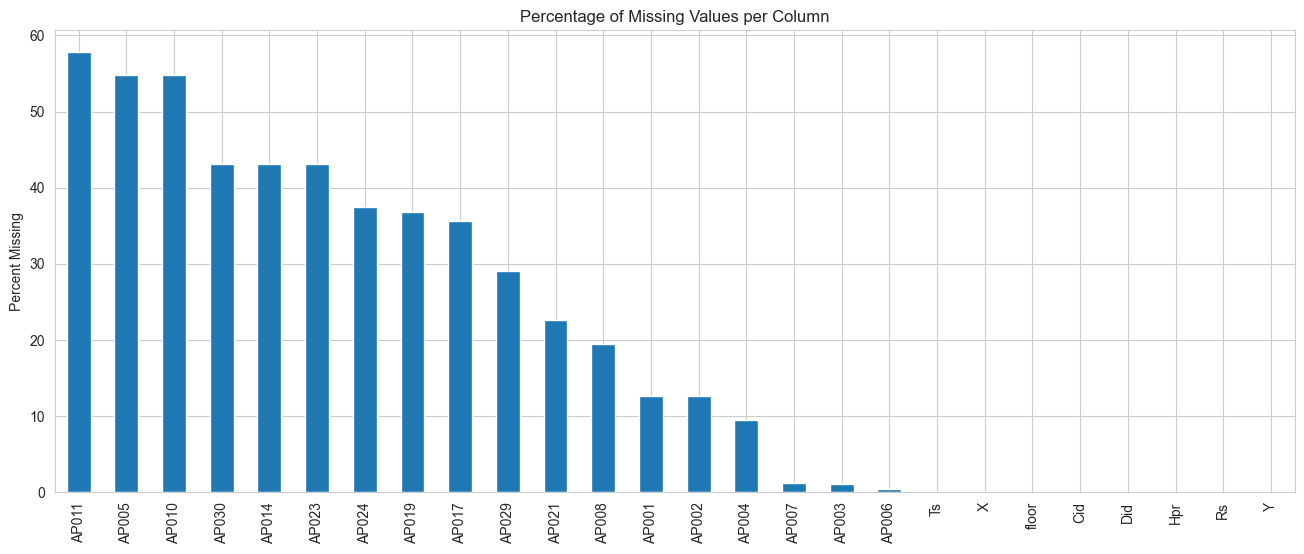

In [112]:
(square_df_cleaned.isna().sum().sort_values(ascending=False) / len(square_df_cleaned) * 100).plot(kind='bar', figsize=(16, 6), ylabel='Percent Missing')
plt.title('Percentage of Missing Values per Column')
plt.show()

In [113]:
# Feature Columns
def get_ap_columns(dataset):
    return [col for col in dataset.columns if col.startswith('AP')]

In [114]:
ap_cols = get_ap_columns(square_df_cleaned)
print(len(ap_cols))
print(ap_cols)

18
['AP001', 'AP002', 'AP003', 'AP004', 'AP005', 'AP006', 'AP007', 'AP008', 'AP010', 'AP011', 'AP014', 'AP017', 'AP019', 'AP021', 'AP023', 'AP024', 'AP029', 'AP030']


In [115]:
cond_cols = ['X','Y']

In [116]:
null_stats_ap_by_did = square_df_cleaned.groupby('Did')[ap_cols].apply(lambda group: group.isna().mean().mean() * 100)
print("Null Stats by Did:")
print(null_stats_ap_by_did)

Null Stats by Did:
Did
D1    33.580165
D2    17.231222
D3    34.256210
D4    34.431077
dtype: float64


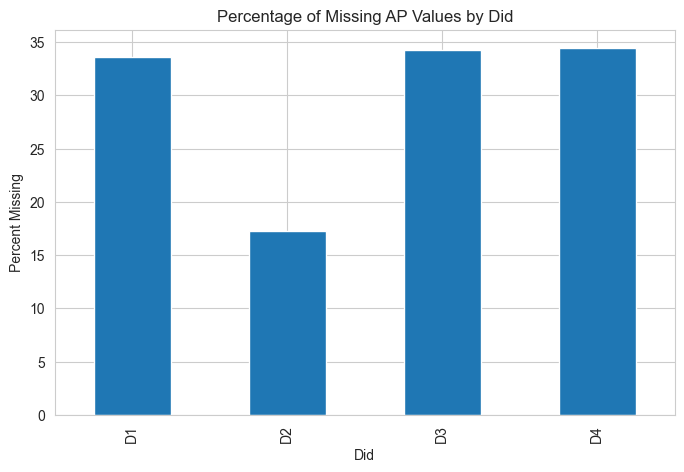

In [117]:
null_stats_ap_by_did.plot(kind='bar', figsize=(8, 5), ylabel='Percent Missing')
plt.title('Percentage of Missing AP Values by Did')
plt.show()

In [118]:
null_stats_ap_by_hpr = square_df_cleaned.groupby('Hpr')[ap_cols].apply(lambda group: group.isna().mean().mean() * 100)
print("Null Stats by Hpr:")
print(null_stats_ap_by_hpr)

Null Stats by Hpr:
Hpr
0    30.696944
1    27.399360
dtype: float64


In [119]:
null_stats_ap_by_rs = square_df_cleaned.groupby('Rs')[ap_cols].apply(lambda group: group.isna().mean().mean() * 100)
print("Null Stats by Rs:")
print(null_stats_ap_by_rs)

Null Stats by Rs:
Rs
0    29.656059
1    27.978358
dtype: float64


# Aggregation by mean

In [120]:
ap_mean_by_xy = square_df_cleaned.groupby(['X', 'Y'])[ap_cols].mean().reset_index()
print(ap_mean_by_xy.shape)
ap_mean_by_xy.head()

(380, 20)


,X,Y,AP001,AP002,AP003,AP004,AP005,AP006,AP007,AP008,AP010,AP011,AP014,AP017,AP019,AP021,AP023,AP024,AP029,AP030
0,16,1,-96.625,-87.5,-73.900000,NaN,NaN,-73.266667,-73.400000,-64.400000,NaN,NaN,NaN,NaN,NaN,-79.933333,-78.400000,NaN,-84.0,-78.800000
1,16,2,NaN,NaN,-65.892857,NaN,NaN,-63.821429,-63.500000,-63.285714,NaN,NaN,NaN,NaN,NaN,-73.928571,-73.142857,NaN,-90.0,-73.000000
2,16,3,NaN,NaN,-66.750000,NaN,NaN,-64.821429,-65.357143,-58.714286,NaN,NaN,NaN,-95.0,-96.0,-71.642857,-72.857143,-89.00,-87.0,-73.642857
3,16,4,NaN,NaN,-60.857143,-96.5,NaN,-63.208333,-62.500000,-53.428571,NaN,NaN,NaN,-97.0,NaN,-71.230769,-73.857143,-89.25,-90.0,-73.785714
4,16,5,-96.000,-91.5,-60.107143,-97.0,NaN,-59.392857,-57.857143,-57.642857,NaN,NaN,NaN,-95.0,-94.0,-68.000000,-76.928571,-96.00,-83.0,-77.071429


## Heatmap plot

In [121]:
def plot_heatmap(dataset, feature):
    # Define grid
    xi = np.linspace(dataset['X'].min(), dataset['X'].max(), 200)
    yi = np.linspace(dataset['Y'].min(), dataset['Y'].max(), 200)
    xi, yi = np.meshgrid(xi, yi)

    # Interpolate (fill missing with nearest to avoid NaN holes)
    zi = griddata(
        (dataset['X'], dataset['Y']),
        dataset[feature],
        (xi, yi),
        method='cubic'
    )

    # Replace NaNs with nearest neighbor interpolation
    zi_nearest = griddata(
        (dataset['X'], dataset['Y']),
        dataset[feature],
        (xi, yi),
        method='nearest'
    )
    zi[np.isnan(zi)] = zi_nearest[np.isnan(zi)]

    # Plot
    plt.figure(figsize=(8,6))
    c = plt.pcolormesh(xi, yi, zi, cmap='viridis', shading='auto')
    plt.colorbar(c, label=f'{feature} Signal Strength (dBm)')
    plt.xlabel("X (m)")
    plt.ylabel("Y (m)")
    plt.title(f"Heat Map for {feature} on 4th Floor")
    plt.show()

MEAN:


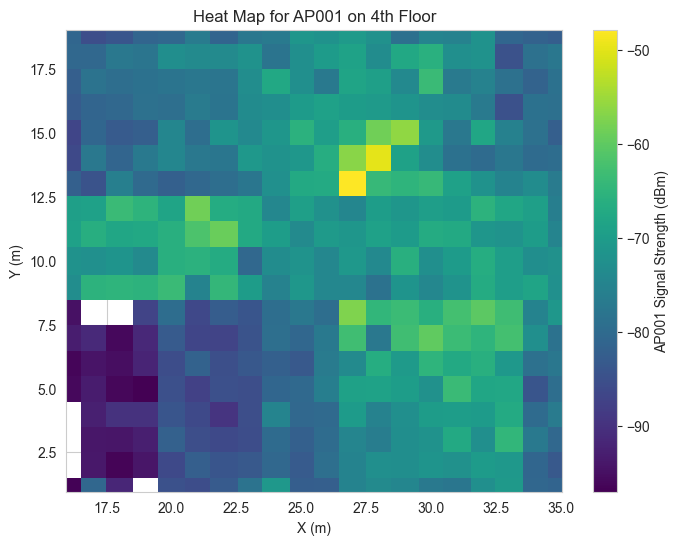

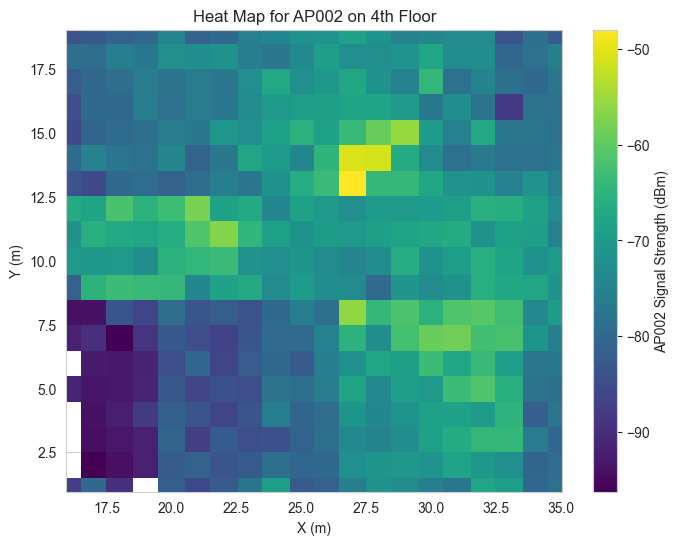

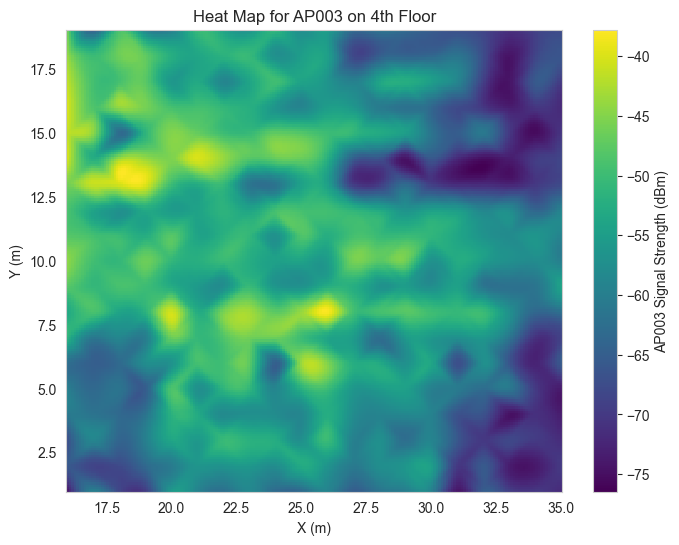

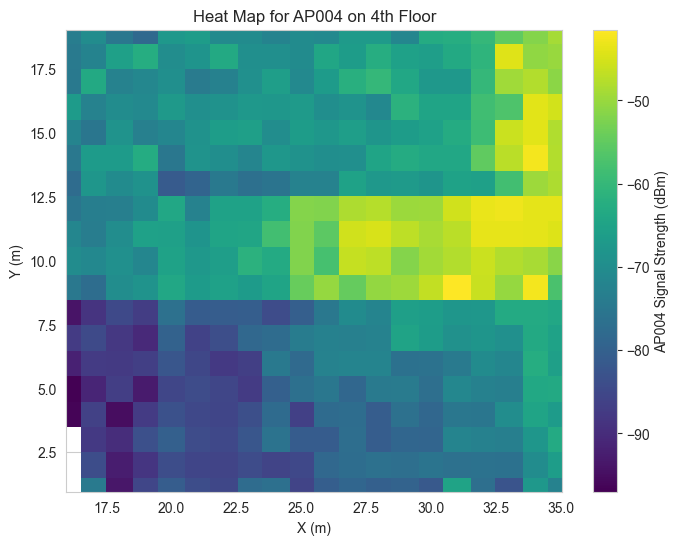

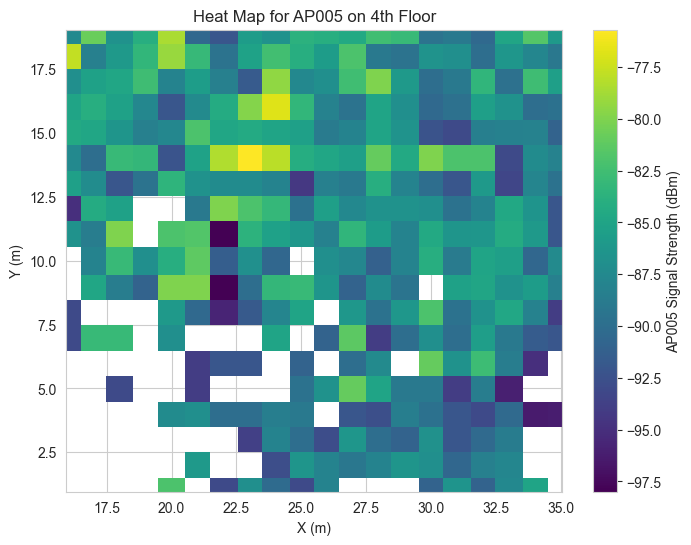

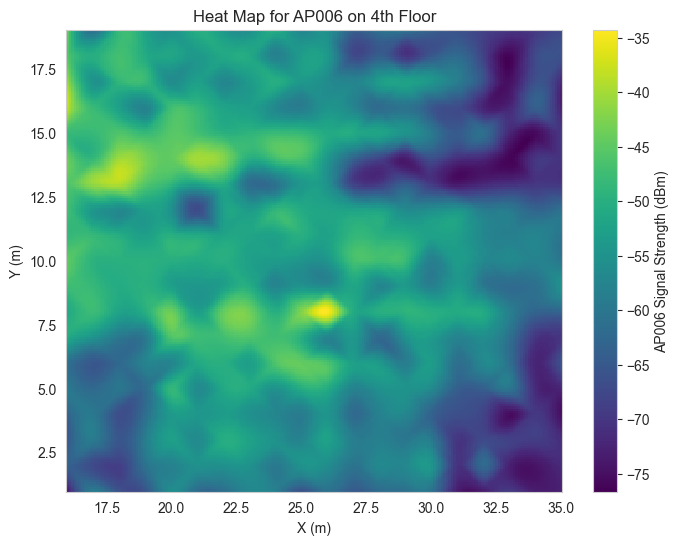

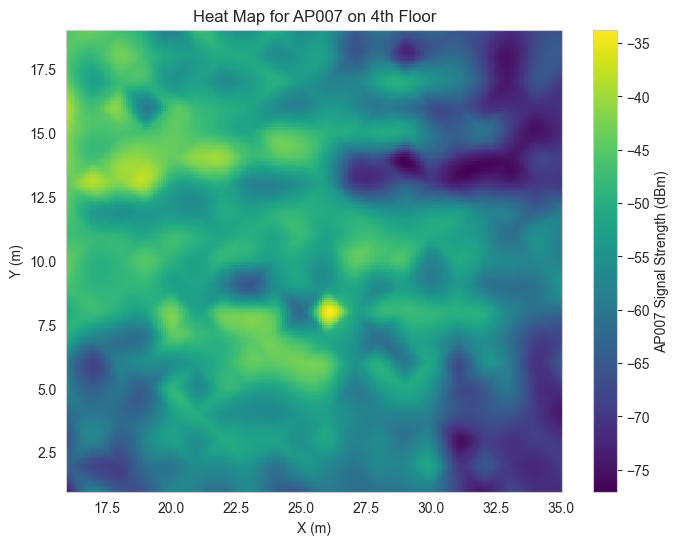

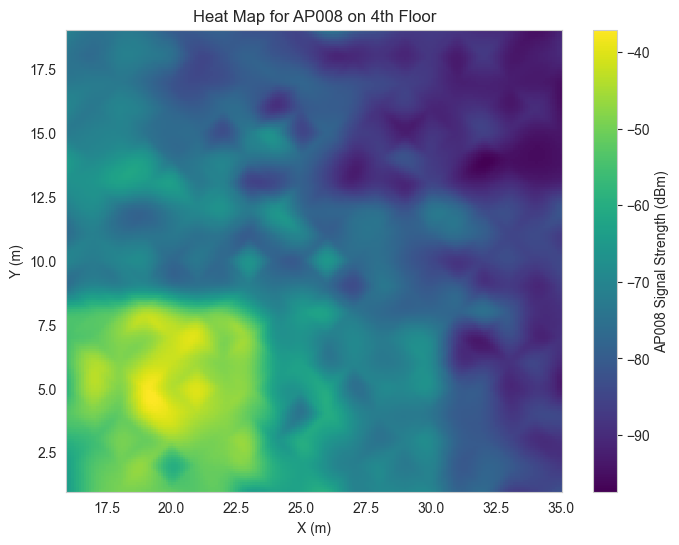

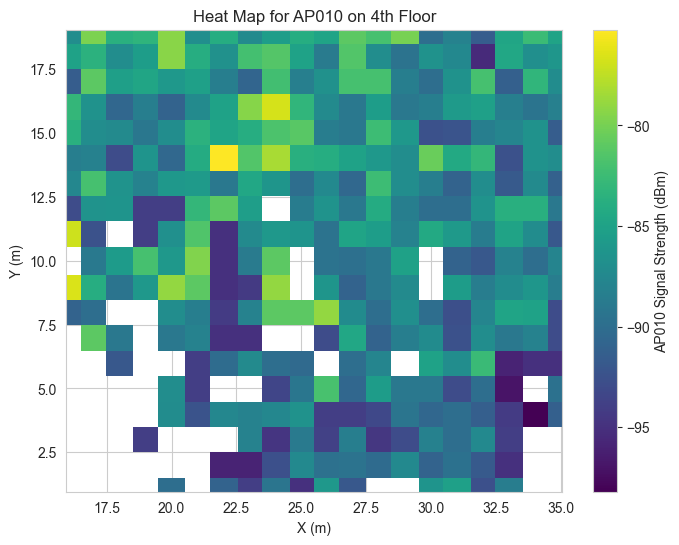

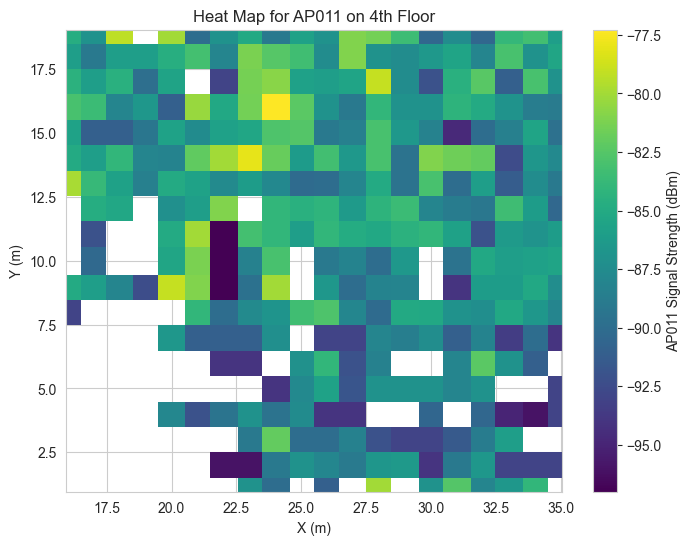

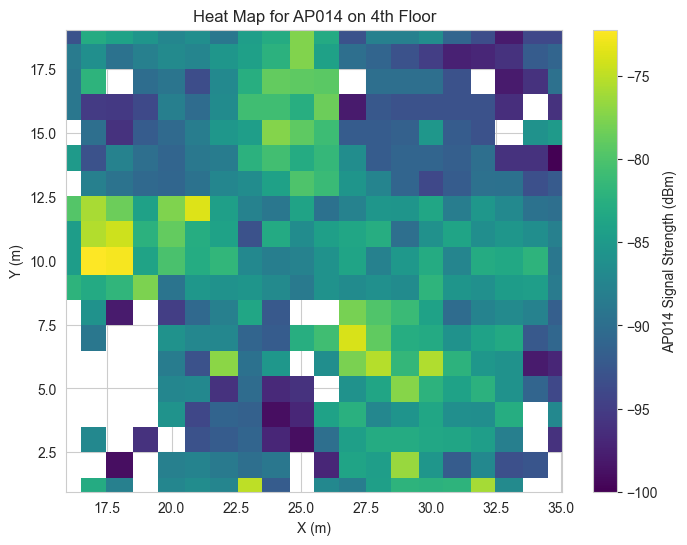

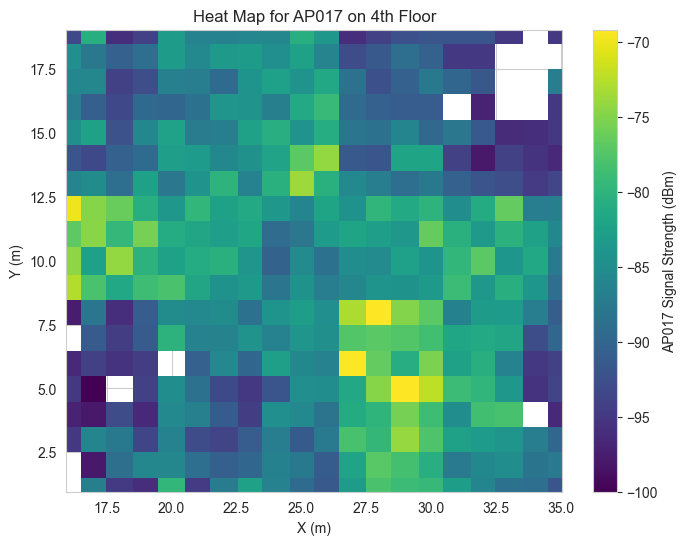

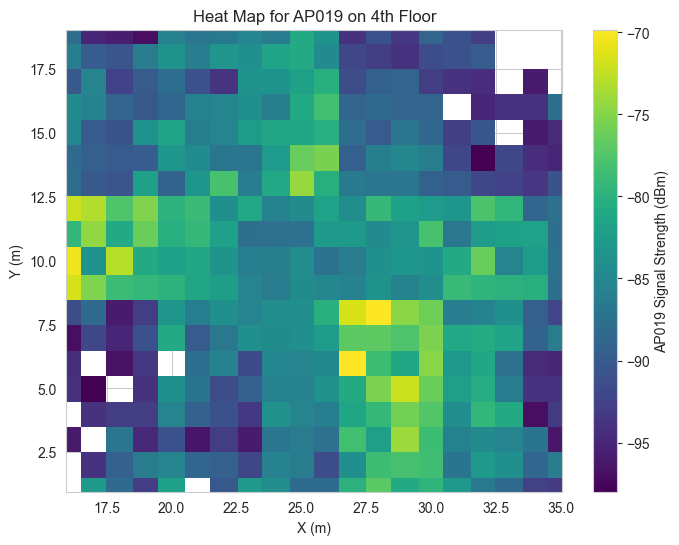

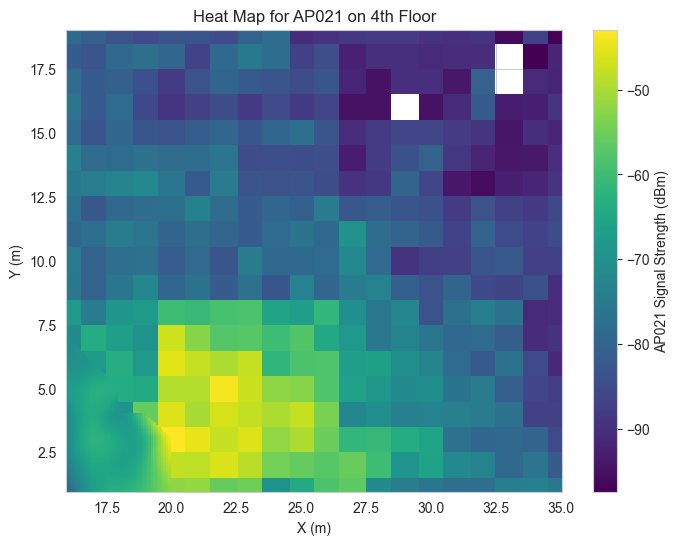

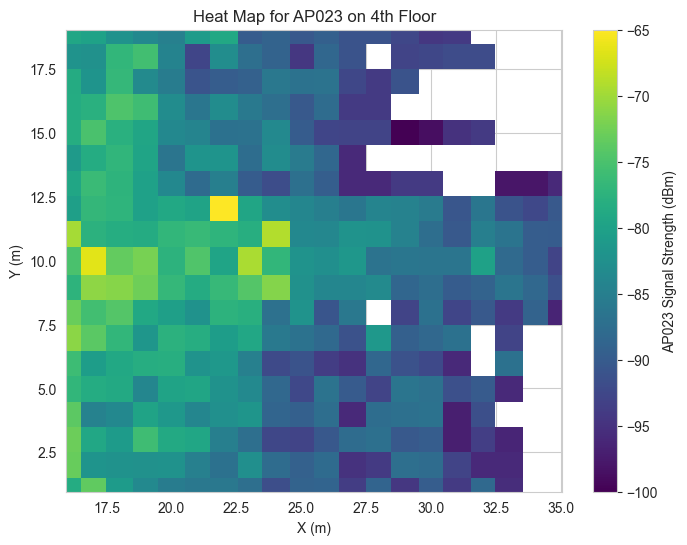

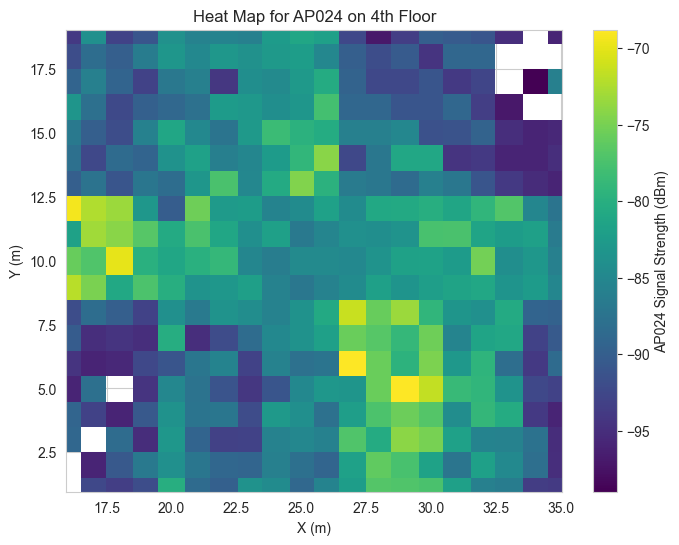

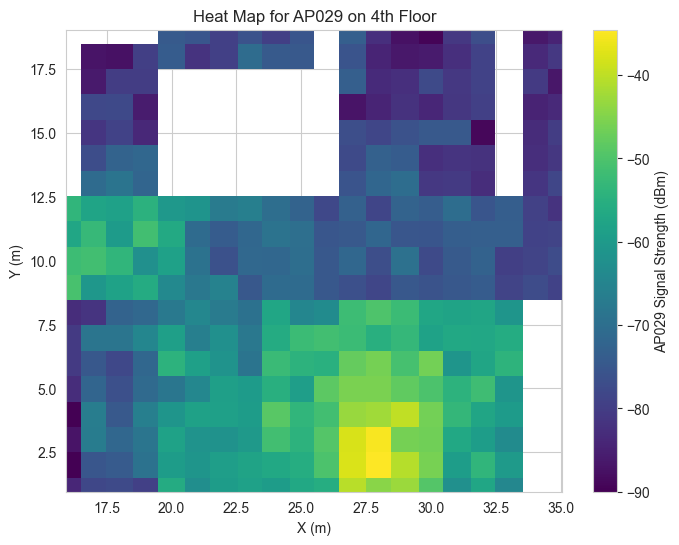

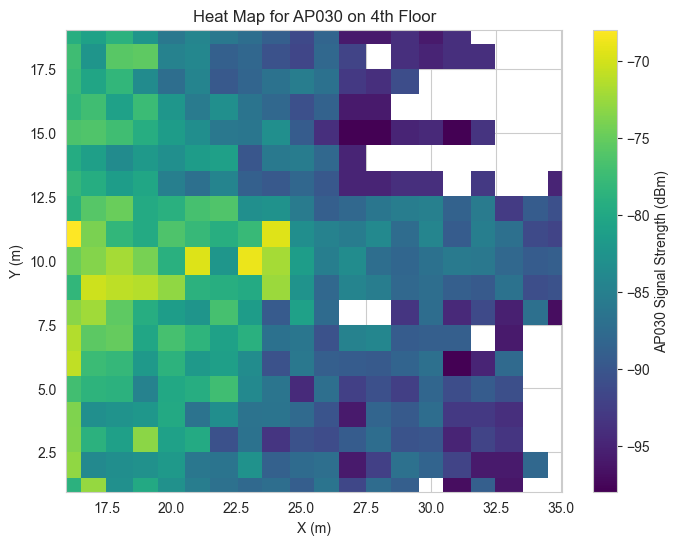

In [122]:
print("MEAN:")
for ap_col in ap_cols:
    plot_heatmap(ap_mean_by_xy, ap_col)

---

## Imputation of Missing values

1) Inverse distance weighting (IDW)
2) Kriging (Ordinary / Universal Kriging)
3) Bicubic / Bilinear Interpolation
4) KNN with Spatial Distance
5) Gaussian Process Regression (GPR)

### Inverse distance weighting (IDW)
The core assumption of IDW is that "closer things are more similar than things further away."

To fill in a missing pixel (let's call it the Target Point), you look at all the surrounding pixels that do have data (Known Points). You calculate the value for the Target Point by taking a weighted average of the Known Points.

In [123]:
ap_mean_by_xy.describe()

,X,Y,AP001,AP002,AP003,AP004,AP005,AP006,AP007,AP008,AP010,AP011,AP014,AP017,AP019,AP021,AP023,AP024,AP029,AP030
count,380.000000,380.000000,374.000000,375.000000,380.000000,377.000000,314.000000,380.000000,380.000000,380.000000,325.000000,303.000000,337.000000,365.000000,362.000000,377.000000,328.000000,369.000000,310.000000,328.000000
mean,25.500000,10.000000,-75.497395,-74.558316,-57.191374,-69.084052,-87.256046,-57.146794,-56.364953,-73.920621,-87.635552,-87.086095,-87.112252,-85.855993,-85.707222,-76.148765,-85.117984,-85.520757,-67.729721,-85.243299
std,5.773884,5.484447,8.301304,8.195147,8.287238,12.192045,3.834907,8.242237,8.485172,13.642541,4.128086,3.718753,5.408931,5.983992,5.785679,12.482415,6.720650,6.040440,12.480705,6.617516
min,16.000000,1.000000,-97.000000,-96.250000,-75.368421,-97.000000,-98.000000,-76.250000,-76.500000,-97.000000,-98.200000,-97.000000,-100.000000,-100.000000,-98.000000,-97.400000,-100.000000,-99.000000,-90.000000,-98.000000
25%,20.750000,5.000000,-80.682292,-79.875000,-63.054688,-76.916667,-89.737500,-62.250992,-62.000000,-84.509615,-90.000000,-89.325000,-91.000000,-90.500000,-89.950000,-85.000000,-90.190476,-90.000000,-78.046875,-89.609091
50%,25.500000,10.000000,-74.417411,-73.593750,-56.375387,-69.857143,-87.292857,-56.000000,-55.178788,-75.333333,-87.571429,-87.000000,-87.000000,-85.636364,-85.585714,-78.777778,-85.928571,-85.428571,-70.706044,-86.138462
75%,30.250000,15.000000,-70.010417,-69.093407,-50.769231,-63.625000,-84.931818,-50.928571,-50.199176,-67.854167,-85.000000,-84.954545,-83.600000,-82.000000,-81.866758,-69.642857,-79.666667,-81.800000,-57.628205,-80.276786
max,35.000000,19.000000,-47.875000,-48.000000,-38.142857,-41.500000,-75.692308,-34.500000,-34.071429,-37.857143,-75.250000,-77.285714,-72.222222,-69.166667,-69.833333,-42.952381,-65.000000,-68.785714,-34.562500,-68.000000


In [124]:
from scipy.spatial.distance import cdist

def impute_and_plot_heatmap(df, x_col, y_col, ap_col, resolution=0.5, power=2):
    """
    Plots a smoothed heatmap and calculates missing values.
    Returns: XX, YY, ZZ (for plot), imputed_values (array), missing_mask (boolean series)
    DOES NOT modify the dataframe in-place.
    """

    # --- PART 1: PREPARE KNOWN DATA ---
    # Drop rows where this specific AP has missing values to get "Known Points"
    known_data = df.dropna(subset=[ap_col])

    x_known = known_data[x_col].values
    y_known = known_data[y_col].values
    z_known = known_data[ap_col].values
    known_coords = np.column_stack((x_known, y_known))

    # --- PART 2: GENERATE GRID & PLOT (Visualization) ---
    x_min, x_max = df[x_col].min(), df[x_col].max()
    y_min, y_max = df[y_col].min(), df[y_col].max()

    grid_x = np.arange(x_min, x_max, resolution)
    grid_y = np.arange(y_min, y_max, resolution)
    XX, YY = np.meshgrid(grid_x, grid_y)

    # Flatten grid for IDW calculation
    grid_coords = np.column_stack((XX.ravel(), YY.ravel()))

    # IDW for Grid
    dists_grid = cdist(grid_coords, known_coords)
    dists_grid[dists_grid == 0] = 1e-10

    weights_grid = 1.0 / np.power(dists_grid, power)
    numerator_grid = np.dot(weights_grid, z_known)
    denominator_grid = weights_grid.sum(axis=1)
    ZZ = (numerator_grid / denominator_grid).reshape(XX.shape)

    # Plot
    plt.figure(figsize=(8,6))
    heatmap = plt.pcolormesh(XX, YY, ZZ, cmap='viridis', shading='auto')
    plt.colorbar(heatmap, label=f'{ap_col} Signal Strength (dBm)')
    plt.title(f'Smoothed Heat Map for {ap_col} (IDW Imputed)')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.show()

    # --- PART 3: CALCULATE MISSING VALUES (For Return) ---
    missing_mask = df[ap_col].isna()
    imputed_values = np.array([]) # Default empty if nothing to fill

    if missing_mask.any():
        # Get coordinates of missing rows
        missing_coords = df.loc[missing_mask, [x_col, y_col]].values

        # IDW for Missing Rows
        dists_missing = cdist(missing_coords, known_coords)
        dists_missing[dists_missing == 0] = 1e-10

        weights_missing = 1.0 / np.power(dists_missing, power)
        numerator_missing = np.dot(weights_missing, z_known)
        denominator_missing = weights_missing.sum(axis=1)
        imputed_values = numerator_missing / denominator_missing

    # Return everything needed to update the DF outside
    return XX, YY, ZZ, imputed_values, missing_mask

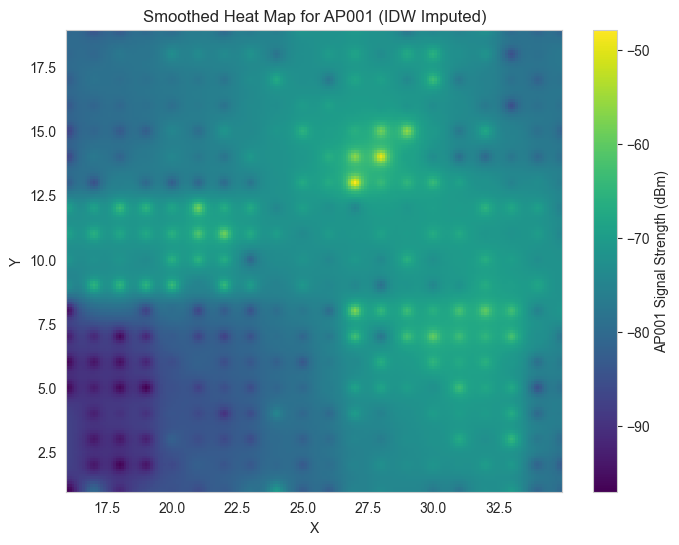

Updated DataFrame: Filled 6 missing values.


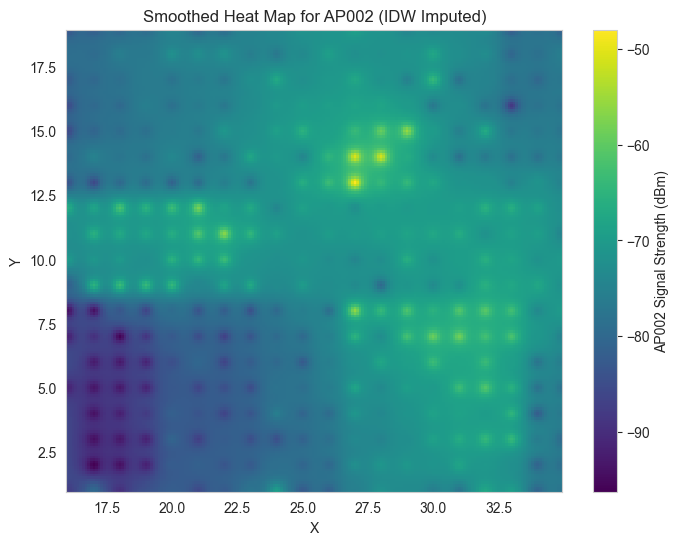

Updated DataFrame: Filled 5 missing values.


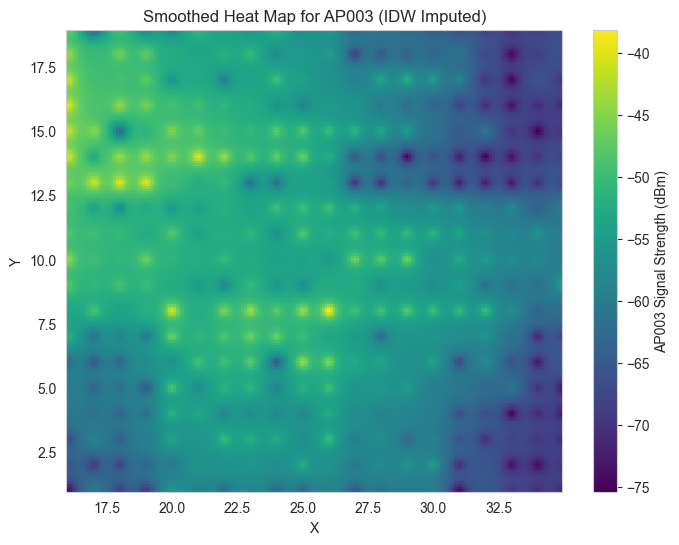


No missing values required filling for AP003.



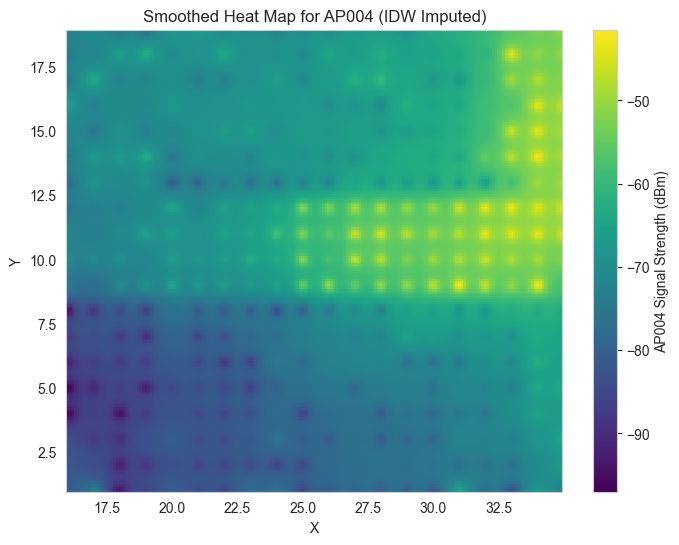

Updated DataFrame: Filled 3 missing values.


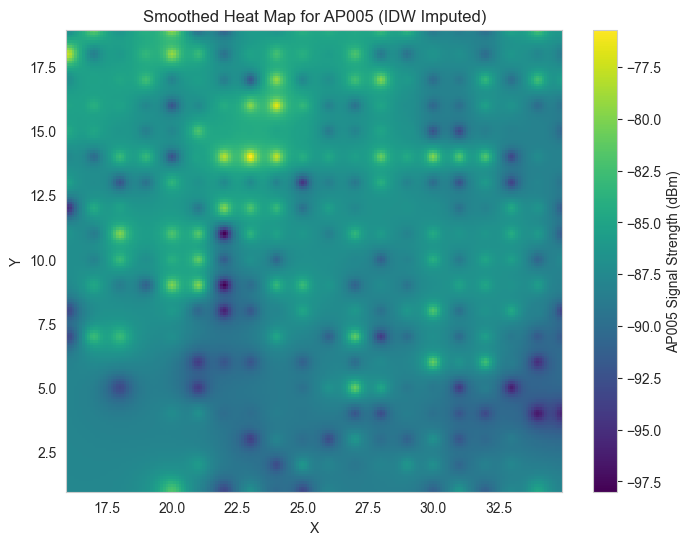

Updated DataFrame: Filled 66 missing values.


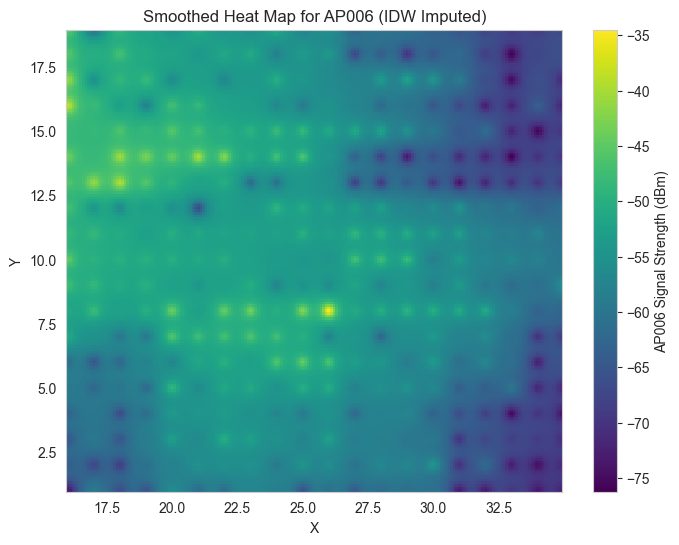


No missing values required filling for AP006.



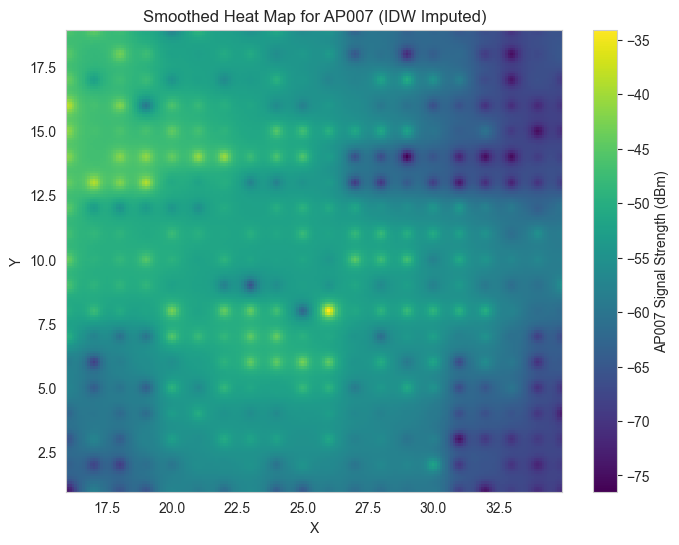


No missing values required filling for AP007.



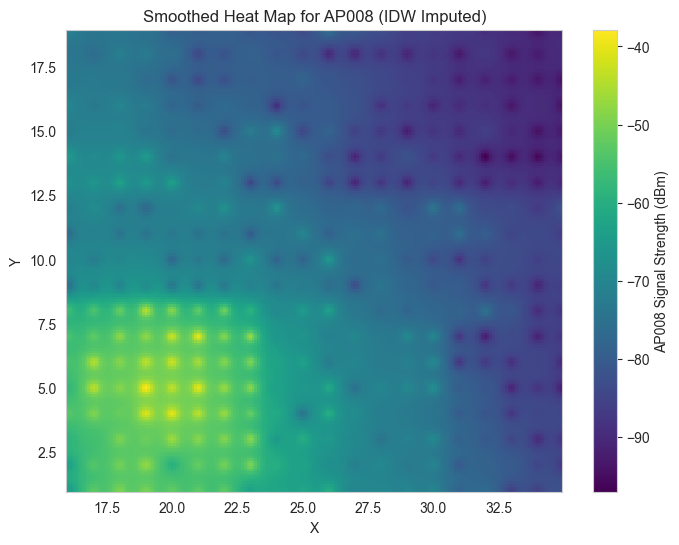


No missing values required filling for AP008.



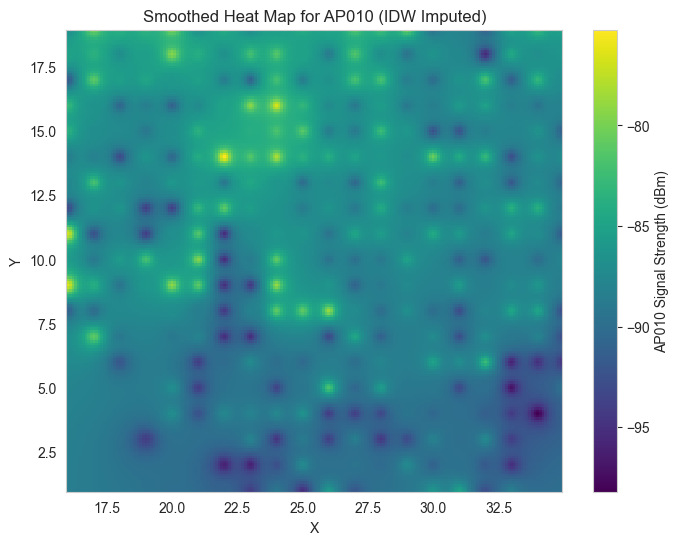

Updated DataFrame: Filled 55 missing values.


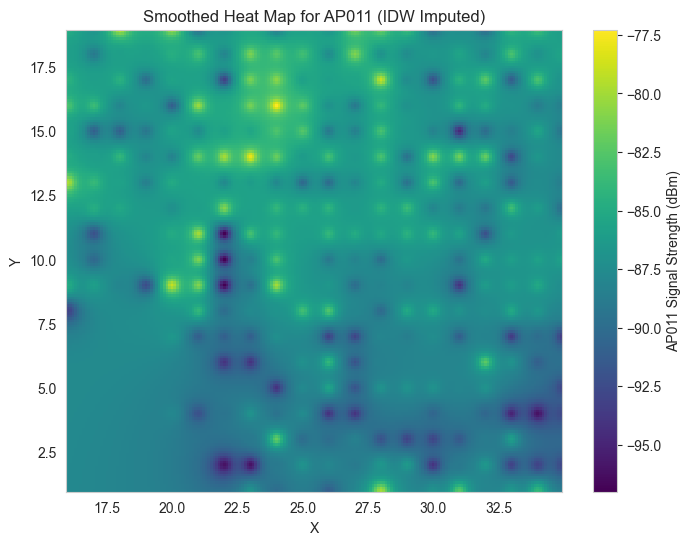

Updated DataFrame: Filled 77 missing values.


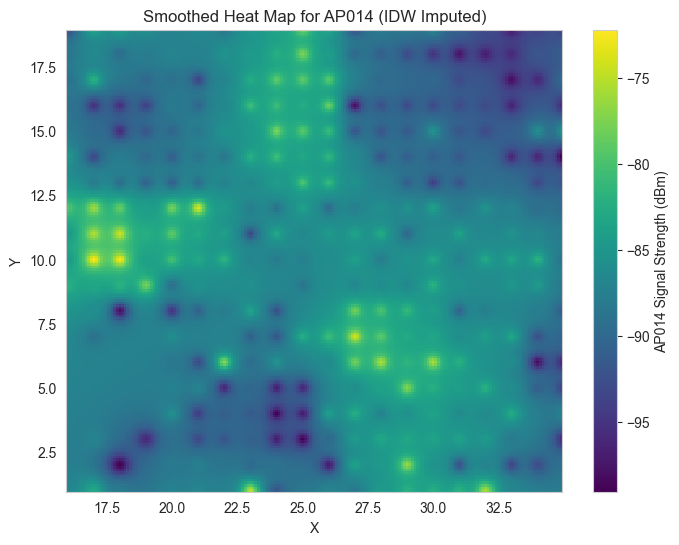

Updated DataFrame: Filled 43 missing values.


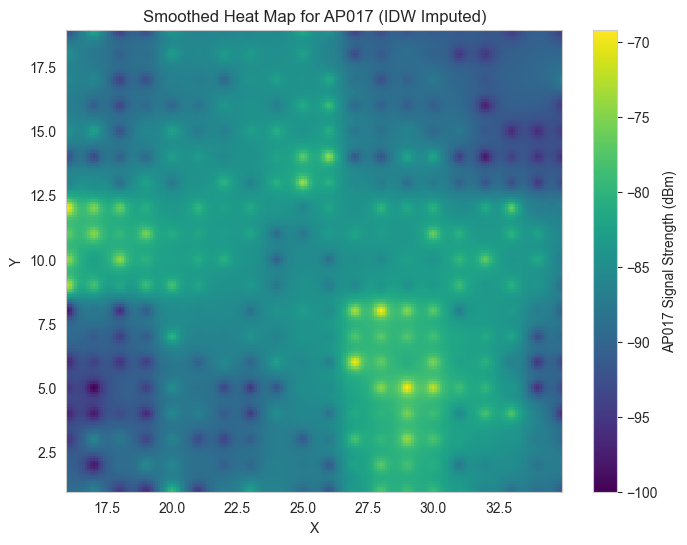

Updated DataFrame: Filled 15 missing values.


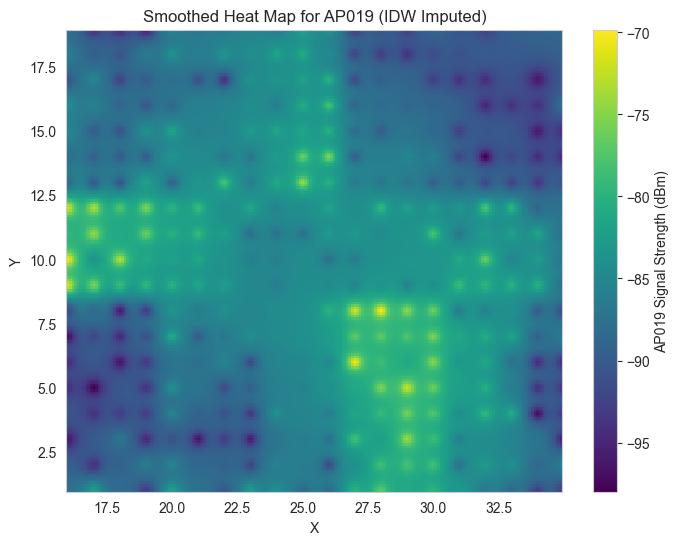

Updated DataFrame: Filled 18 missing values.


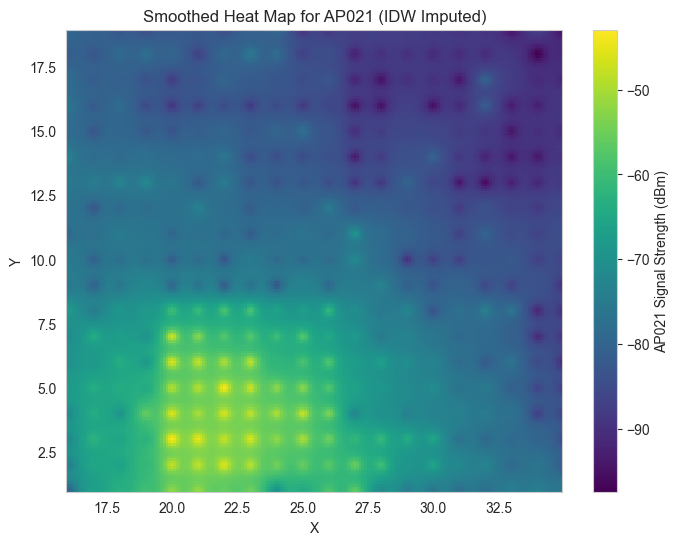

Updated DataFrame: Filled 3 missing values.


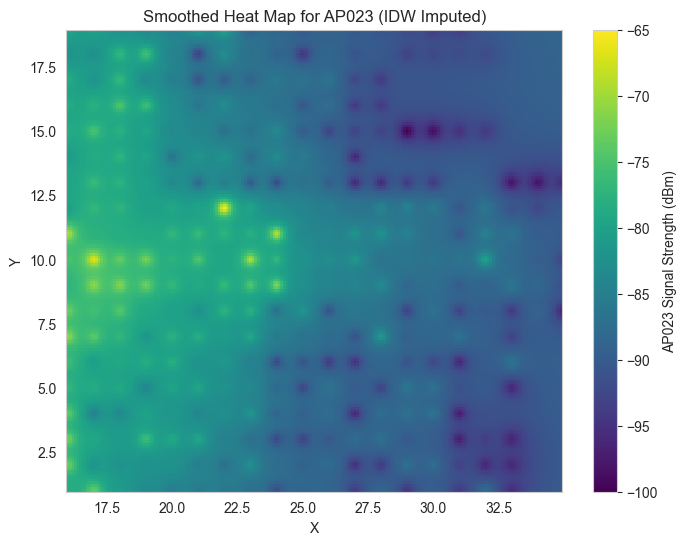

Updated DataFrame: Filled 52 missing values.


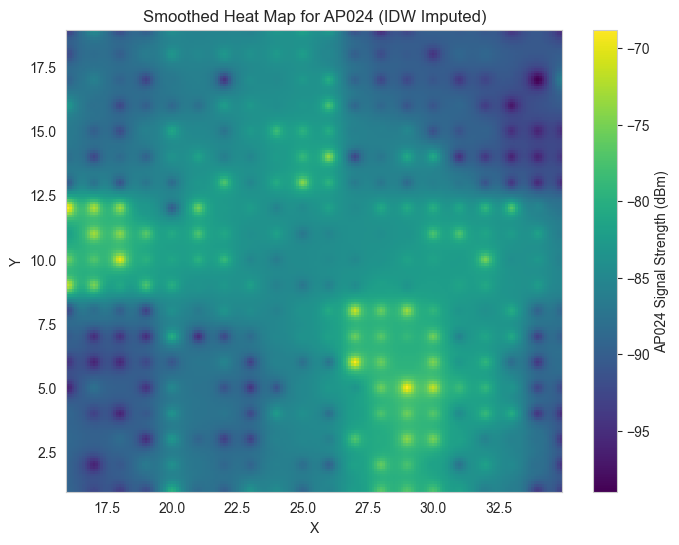

Updated DataFrame: Filled 11 missing values.


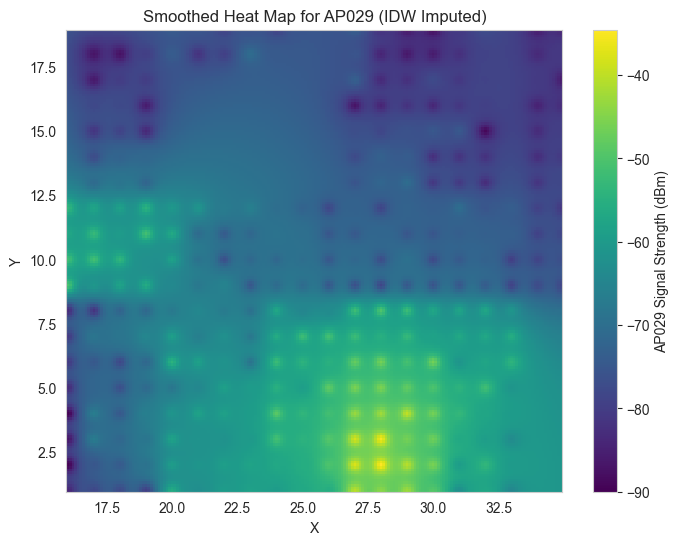

Updated DataFrame: Filled 70 missing values.


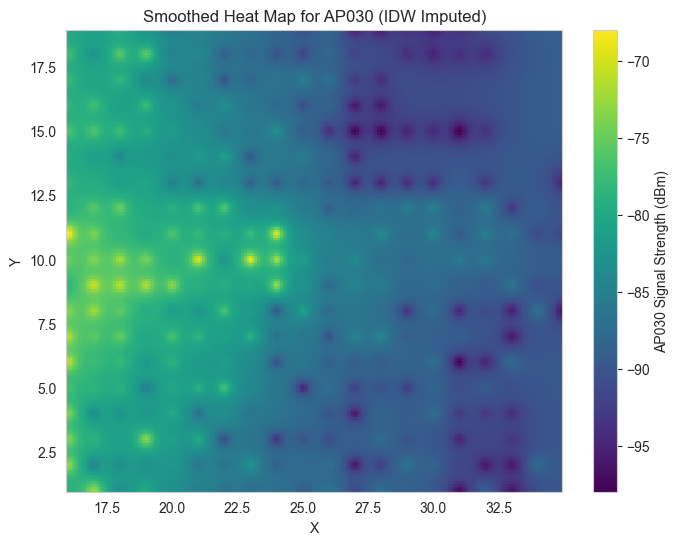

Updated DataFrame: Filled 52 missing values.


In [125]:
for ap_col in ap_cols:
    XX, YY, ZZ, new_values, mask = impute_and_plot_heatmap(
        df=ap_mean_by_xy,
        x_col='X',
        y_col='Y',
        ap_col=ap_col,
        resolution=0.1,
        power=2
    )

    # We use the 'mask' to ensure we only fill the exact rows that were calculated
    if len(new_values) > 0:
        ap_mean_by_xy.loc[mask, ap_col] = new_values
        print(f"Updated DataFrame: Filled {len(new_values)} missing values.")
    else:
        print(
f"""
================================================
No missing values required filling for {ap_col}.
================================================
"""
        )


---

## Sampling Dataset Subset

In [126]:
def subsample_every_n(df, N, origin=(None,None), tol=1e-8):
    """
    Split df into two parts:
      • df_kept: rows where (X−x0) and (Y−y0) are multiples of N
      • df_rest: all the other rows

    Parameters
    ----------
    df : DataFrame with columns 'X','Y'
    N  : float           the grid spacing you want (e.g. 5.0)
    origin : (x0,y0)     the “zero” of your grid; if None, uses (min X, min Y)
    tol : float          tolerance for floating-point modulo

    Returns
    -------
    df_kept, df_rest : DataFrames
    """
    df2 = df.copy()

    # 1) determine grid origin
    x0 = origin[0] if origin[0] is not None else df2['X'].min()
    y0 = origin[1] if origin[1] is not None else df2['Y'].min()

    # 2) compute offsets
    dx = df2['X'] - x0
    dy = df2['Y'] - y0

    # 3) boolean mask for “on-grid” points
    on_grid = (
        np.isclose(dx.mod(N), 0.0, atol=tol) &
        np.isclose(dy.mod(N), 0.0, atol=tol)
    )

    # 4) split
    df_kept = df2.loc[on_grid].reset_index(drop=True)
    df_rest = df2.loc[~on_grid].reset_index(drop=True)

    return df_kept, df_rest

In [127]:
def fraction(actual, orig):
    return actual.shape[0] / orig.shape[0] * 100

## Table Diffusion Model

In [128]:
def get_beta(t: int, T: int) -> float:
    return (1.0 - math.cos(math.pi * t / T)) / 2.0

def timestep_embedding(timesteps: torch.Tensor, dim: int) -> torch.Tensor:
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(0, half, device=timesteps.device) / max(half - 1, 1))
    args = timesteps.float().unsqueeze(1) * freqs.unsqueeze(0)
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
    if dim % 2 == 1:
        emb = nn.functional.pad(emb, (0, 1))
    return emb

# Tabular U-Net-like MLP backbone
class TabularUNet(nn.Module):
    def __init__(self, input_dim: int, cond_dim: int, time_emb_dim: int, hidden: list[int] = [512, 256, 128]):
        super().__init__()
        # Heads for time and condition
        self.t_proj = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, hidden[0])
        )
        self.c_proj = nn.Sequential(
            nn.Linear(cond_dim, hidden[0]),
            nn.SiLU()
        )

        # Encoder blocks
        enc_dims = [input_dim + hidden[0]*2] + hidden[:-1]
        self.encoder = nn.ModuleList(
            nn.Sequential(nn.Linear(i, o), nn.SiLU())
            for i, o in zip(enc_dims, hidden))

        # Decoder blocks
        dec_dims = hidden[::-1]
        self.decoder = nn.ModuleList(
            nn.Sequential(nn.Linear(i*2, o), nn.SiLU())
            for i, o in zip(dec_dims[:-1], dec_dims[1:]))

        # Final layer
        self.out = nn.Linear(hidden[0], input_dim)

    def forward(self, x: torch.Tensor, cond: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        # x: [batch, input_dim]
        # cond: [batch, cond_dim]
        # t_emb: [batch, time_emb_dim]
        t_h = self.t_proj(t_emb)
        c_h = self.c_proj(cond)

        h = torch.cat([x, c_h, t_h], dim=1)
        skips = []
        # Encode
        for enc in self.encoder:
            h = enc(h)
            skips.append(h)
        # Decode
        for dec in self.decoder:
            skip = skips.pop()
            h = torch.cat([h, skip], dim=1)
            h = dec(h)
        return self.out(h)

# Diffusion model with Tabular U-Net backbone
class TableDiffusion(nn.Module):
    def __init__(self, rss_dim: int, cond_dim: int = 2, time_emb_dim: int = 128, hidden: list[int] = [512, 256, 128]):
        super().__init__()
        self.time_emb_dim = time_emb_dim
        self.unet = TabularUNet(
            rss_dim,
            cond_dim,
            time_emb_dim,
            hidden
        )

    def forward(self, noised_rss: torch.Tensor, cond: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = timestep_embedding(t, self.time_emb_dim)
        return self.unet(noised_rss, cond, t_emb)


# Training loop (noise-prediction objective)
def train_table_diffusion(
    model: TableDiffusion,
    X_cond: torch.Tensor,
    Y_rss: torch.Tensor,
    steps: int = 100,
    batch_size: int = 64,
    epochs: int = 100,
    lr: float = 6e-4,
):
    device = (
        torch.device("mps") if torch.backends.mps.is_available()
        else torch.device("cuda") if torch.cuda.is_available()
        else torch.device("cpu")
    )
    print("Device:", device)
    model.to(device)
    ds = torch.utils.data.TensorDataset(X_cond, Y_rss)
    dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)
    opt = optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()
    model.train()

    for ep in range(1, epochs+1):
        total = 0.0
        model.train()
        for cond_b, rss_b in dl:
            cond_b, rss_b = cond_b.to(device), rss_b.to(device)
            loss_acc = 0.0
            for t in range(steps):
                beta = get_beta(t, steps)
                noise = torch.randn_like(rss_b) * math.sqrt(beta)
                x_t = rss_b + noise
                t_vec = torch.full((rss_b.size(0),), t, dtype=torch.long, device=device)
                pred = model(x_t, cond_b, t_vec)
                loss_acc += mse(pred, noise)
            loss = loss_acc / steps
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item()
        if ep % 10 == 0 or ep == 1:
            print(f"[TableDiffusion] Epoch {ep}/{epochs} - loss: {total/len(dl):.4f}")
    return model

# Reverse sampling (denoise from Gaussian)
def sample_table_diffusion(
        model: TableDiffusion,
        X_cond: torch.Tensor,
        diffusion_steps: int = 100
) -> np.ndarray:
    device = (
    torch.device("mps") if torch.backends.mps.is_available()
        else torch.device("cuda") if torch.cuda.is_available()
        else torch.device("cpu")
    )
    print("Device:", device)
    model.eval()
    X_cond = X_cond.to(device)
    print(X_cond.shape)
    n, _ = X_cond.shape
    rss_dim = model.unet.out.out_features
    samples = torch.randn(n, rss_dim, device=device)

    with torch.no_grad():
        for t in reversed(range(diffusion_steps)):
            beta = get_beta(t, diffusion_steps)
            t_vec = torch.full((n,), t, dtype=torch.long, device=device)
            pred_eps = model(samples, X_cond, t_vec)
            samples = samples - pred_eps * math.sqrt(beta)
        return samples.cpu().numpy()

In [129]:
# Validation noise-prediction loss (quick proxy)
def eval_noise_mse(model, Xc, Yr, steps=50):
    device = next(model.parameters()).device
    mse = nn.MSELoss()
    model.eval()
    with torch.no_grad():
        Xc, Yr = Xc.to(device), Yr.to(device)
        tot = 0.0
        for t in range(steps):
            beta = get_beta(t, steps)
            eps = torch.randn_like(Yr) * math.sqrt(beta)
            x_t = Yr + eps
            t_vec = torch.full((Yr.size(0),), t, dtype=torch.long, device=device)
            pred = model(x_t, Xc, t_vec)
            tot += mse(pred, eps).item()
        return tot / steps


In [130]:
def train_tdm(dataset, ap_cols, cond_cols, steps=75, batch_size=64, epochs=200, lr=6.3e-4):
    # Replace missing APs with a sentinel before scaling
    td_train_filled = dataset.copy()
    td_train_filled[ap_cols] = td_train_filled[ap_cols].fillna(-110)

    # Train/val/test split
    X_cond = td_train_filled[cond_cols].values.astype("float32")
    Y_rss = td_train_filled[ap_cols].values.astype("float32")

    # Scale RSS targets only
    rss_scaler = StandardScaler()
    Y_rss_s = rss_scaler.fit_transform(Y_rss)

    print(f"Y_rss.shape: {Y_rss_s.shape}")

    # Tensors for X
    X_cond_t  = torch.tensor(X_cond,   dtype=torch.float32)
    # Tensors for Y
    Y_rss_t  = torch.tensor(Y_rss_s, dtype=torch.float32)

    # Instantiate, train, and demonstrate generation at custom coordinates
    rss_dim = len(ap_cols)
    td_model = TableDiffusion(rss_dim=rss_dim, cond_dim=2, time_emb_dim=128)

    td_model = train_table_diffusion(
        td_model,
        X_cond_t,
        Y_rss_t,
        steps=steps,          # can tune (e.g., 50–200)
        batch_size=batch_size,
        epochs=epochs,        # can tune
        lr=lr
    )

    val_noise_mse = eval_noise_mse(td_model, X_cond_t, Y_rss_t, steps=50)
    print(f"[TableDiffusion] Validation noise-prediction MSE: {val_noise_mse:.4f}")

    return td_model, X_cond_t, Y_rss_t, rss_scaler


In [131]:
def generate_rss_values(model, coords_dataset, rss_scaler, diffusion_steps=100):
    """
    Generate synthetic RSS values for the given condition columns.
    """

    gen_rss_values = sample_table_diffusion(model, coords_dataset, diffusion_steps)

    # Inverse transform to get the RSS values in the original scale
    synthetic_rss = rss_scaler.inverse_transform(gen_rss_values)

    synthetic_rss_df = pd.DataFrame(synthetic_rss, columns=ap_cols)
    return synthetic_rss_df

In [132]:
def generate_synthetic_rss(td_model, scaler, coordinates):
    coords_t = torch.tensor(coordinates.values,  dtype=torch.float32)
    synthetic_rss  = generate_rss_values(td_model, coords_t, scaler)

    synthetic_dataset = pd.concat([synthetic_rss, coordinates], axis=1)
    return synthetic_dataset

## KNN

In [133]:
def knn_regression(dataset):
    # Replace NaN with -110
    X_ap = dataset.drop(columns=cond_cols).fillna(-110).values
    y_xy = dataset[cond_cols].values

    scaler=StandardScaler()
    X_ap = scaler.fit_transform(X_ap)

    # KNN multi-output
    knn_xy = KNeighborsRegressor(
        n_neighbors=4,
        weights='distance',  # closer fingerprints count more
        metric='euclidean')
    knn_xy.fit(X_ap, y_xy)
    return knn_xy, scaler


In [134]:
def plot_indoor_localization_map(true_locations, predicted_locations_orig, predicted_locations_synth, title):
    plt.figure(figsize=(8,6))
    plt.scatter(true_locations[:,0], true_locations[:,1], c='yellow', marker='x',s=100, label="True locations")
    plt.scatter(predicted_locations_orig[:,0], predicted_locations_orig[:,1], c='b', alpha=0.5, label="KNN (model trained data)")
    plt.scatter(predicted_locations_synth[:,0], predicted_locations_synth[:,1], c='r', alpha=0.5, label="KNN (synthetic data)")
    # plt.scatter(pred_locations_combined[:,0], pred_locations_combined[:,1], c='g', alpha=0.5, label="KNN (combined data)")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(title)
    plt.legend()
    plt.show()

In [135]:
def plot_indoor_localization_results(true_locations, predicted_locations, title):
    # Plotting
    plt.figure(figsize=(8, 6))

    # Scatter plots for the points
    plt.scatter(true_locations[:, 0], true_locations[:, 1], c='yellow', marker='x', s=100, label="True locations")
    plt.scatter(predicted_locations[:, 0], predicted_locations[:, 1], c='r', alpha=0.5, label="KNN (model trained data)")


    # Draw lines connecting the true points with synthetic predictions
    for i in range(len(true_locations)):
        plt.plot([true_locations[i, 0], predicted_locations[i, 0]],
                [true_locations[i, 1], predicted_locations[i, 1]],
                c='red', linestyle=':', linewidth=1)  # Lines between true and synthetic

    # Labels and title
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(title)
    plt.legend()

    # Show the plot
    plt.show()

In [136]:
# Define a function to compute the Euclidean distance error.
def compute_localization_errors(true_locations, predicted_locations):
    errors = np.sqrt(np.sum((true_locations - predicted_locations)**2, axis=1))
    return errors

## Training and Model Evaluation

In [137]:
all_coords = ap_mean_by_xy[cond_cols]

In [138]:
print(ap_mean_by_xy.shape)
ap_mean_by_xy.head(3)

(380, 20)


,X,Y,AP001,AP002,AP003,AP004,AP005,AP006,AP007,AP008,AP010,AP011,AP014,AP017,AP019,AP021,AP023,AP024,AP029,AP030
0,16,1,-96.625000,-87.500000,-73.900000,-80.327144,-87.690937,-73.266667,-73.400000,-64.400000,-88.538851,-87.774284,-86.861787,-89.245375,-87.674971,-79.933333,-78.400000,-89.281156,-84.0,-78.800000
1,16,2,-87.580143,-85.925068,-65.892857,-82.133734,-87.733384,-63.821429,-63.500000,-63.285714,-88.486005,-87.746351,-87.520906,-90.642517,-89.615901,-73.928571,-73.142857,-89.512999,-90.0,-73.000000
2,16,3,-87.224442,-86.249212,-66.750000,-84.312676,-87.802420,-64.821429,-65.357143,-58.714286,-88.368352,-87.702312,-87.569276,-95.000000,-96.000000,-71.642857,-72.857143,-89.000000,-87.0,-73.642857


In [162]:
training_df, test_df = subsample_every_n(ap_mean_by_xy, 2, (0,0))

Train with 70%, 50%, 40%, 20%, 15% of real dataset. Split the dataset by the closest distance (1m, 2m, 3m)

In [163]:
print(fraction(training_df, ap_mean_by_xy))
print(fraction(test_df, ap_mean_by_xy))

23.684210526315788
76.31578947368422


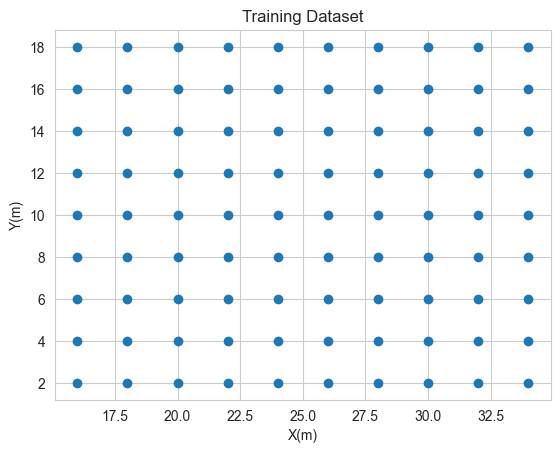

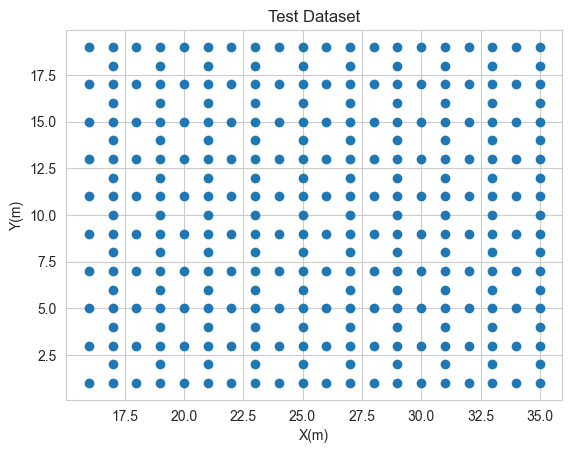

In [164]:
plot_floor_data(training_df, "Training Dataset")
plot_floor_data(test_df, "Test Dataset")

### Training TDDM

In [165]:
td_model, X_t, Y_t, scaler = train_tdm(training_df, ap_cols=get_ap_columns(training_df), cond_cols=cond_cols, epochs=250, batch_size=64)

Y_rss.shape: (90, 18)
Device: mps
[TableDiffusion] Epoch 1/250 - loss: 0.5671
[TableDiffusion] Epoch 10/250 - loss: 0.4869
[TableDiffusion] Epoch 20/250 - loss: 0.4895
[TableDiffusion] Epoch 30/250 - loss: 0.4773
[TableDiffusion] Epoch 40/250 - loss: 0.4599
[TableDiffusion] Epoch 50/250 - loss: 0.4524
[TableDiffusion] Epoch 60/250 - loss: 0.4530
[TableDiffusion] Epoch 70/250 - loss: 0.7549
[TableDiffusion] Epoch 80/250 - loss: 0.4075
[TableDiffusion] Epoch 90/250 - loss: 0.3520
[TableDiffusion] Epoch 100/250 - loss: 0.4162
[TableDiffusion] Epoch 110/250 - loss: 0.2787
[TableDiffusion] Epoch 120/250 - loss: 0.2666
[TableDiffusion] Epoch 130/250 - loss: 0.2190
[TableDiffusion] Epoch 140/250 - loss: 0.1970
[TableDiffusion] Epoch 150/250 - loss: 0.1752
[TableDiffusion] Epoch 160/250 - loss: 0.1631
[TableDiffusion] Epoch 170/250 - loss: 0.1515
[TableDiffusion] Epoch 180/250 - loss: 0.1521
[TableDiffusion] Epoch 190/250 - loss: 0.1516
[TableDiffusion] Epoch 200/250 - loss: 0.1386
[TableDiffu

In [167]:
synthetic_df = generate_synthetic_rss(td_model=td_model, scaler=scaler, coordinates=test_df[cond_cols])

Device: mps
torch.Size([290, 2])


### KNN Evaluation

In [168]:
X_ap_train = training_df[get_ap_columns(training_df)].fillna(-110).values
y_xy_train = training_df[cond_cols].values

X_ap_test = test_df[get_ap_columns(test_df)].fillna(-110).values
y_xy_test = test_df[cond_cols].values

In [169]:
X_ap_synth = synthetic_df[get_ap_columns(synthetic_df)].fillna(-110).values
y_xy_synth = synthetic_df[cond_cols].values

In [187]:
from sklearn.model_selection import GridSearchCV

knn_scaler=StandardScaler()
X_ap_train_scaled = knn_scaler.fit_transform(X_ap_train)

# --- Custom Weight Function (1 / distance^2) ---
def inverse_squared_weight(distances):
    # Avoid division by zero for exact matches
    # (replace 0 with a tiny number)
    distances = np.maximum(distances, 1e-10)
    return 1.0 / (distances ** 2)

# KNN multi-output
knn = KNeighborsRegressor(
    weights=inverse_squared_weight,
    metric='manhattan')

param_grid = {'n_neighbors': range(3, 31)}
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_search.fit(X_ap_train_scaled, y_xy_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_}")

knn_best = grid_search.best_estimator_

pred_locations_test = knn_best.predict(knn_scaler.transform(X_ap_test))

Best parameters: {'n_neighbors': 5}
Best score: -3.4191286874630875


In [188]:
np.mean(compute_localization_errors(y_xy_test, pred_locations_test))

2.534980601797914

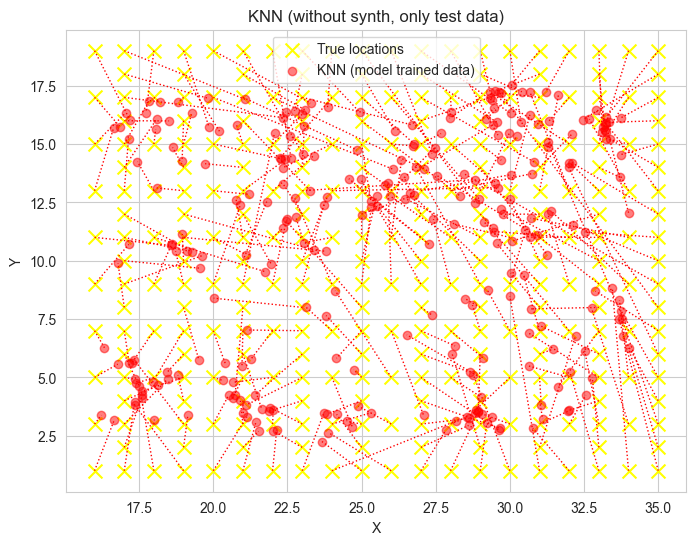

In [189]:
plot_indoor_localization_results(y_xy_test, pred_locations_test, "KNN (without synth, only test data)")

In [190]:
X_combined = pd.concat([pd.DataFrame(X_ap_train), pd.DataFrame(X_ap_synth)], axis=0).values
y_combined = pd.concat([pd.DataFrame(y_xy_train), pd.DataFrame(y_xy_synth)], axis=0).values

In [191]:
from sklearn.model_selection import GridSearchCV

knn_scaler=StandardScaler()
X_combined_scaled = knn_scaler.fit_transform(X_combined)

# KNN multi-output
knn = KNeighborsRegressor(
    weights=inverse_squared_weight,  # closer fingerprints count more
    metric='manhattan')

param_grid = {'n_neighbors': range(3, 31)}
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_search.fit(X_combined_scaled, y_combined)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_}")

knn_best = grid_search.best_estimator_

pred_locations_test = knn_best.predict(knn_scaler.transform(X_ap_test))

Best parameters: {'n_neighbors': 4}
Best score: -1.416632355306421


In [192]:
np.mean(compute_localization_errors(y_xy_test, pred_locations_test))

2.58145875717913

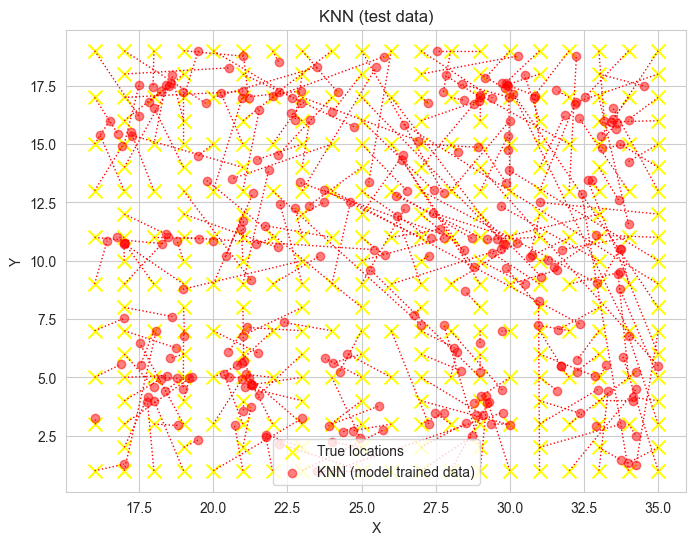

In [193]:
plot_indoor_localization_results(y_xy_test, pred_locations_test, "KNN (test data)")

---

# Aggregation by median

In [56]:
ap_median_by_xy = square_df_cleaned.groupby(['X', 'Y'])[ap_cols].median().reset_index()
print(ap_median_by_xy.shape)
ap_median_by_xy.head()

(380, 23)


,X,Y,AP001,AP002,AP003,AP004,AP005,AP006,AP007,AP008,...,AP017,AP019,AP021,AP023,AP024,AP025,AP029,AP030,AP046,AP053
0,16,1,-96.0,-84.0,-74.0,NaN,NaN,-72.0,-74.0,-64.0,...,NaN,NaN,-80.0,-80.0,NaN,NaN,-84.0,-81.0,-77.0,-75.0
1,16,2,NaN,NaN,-65.5,NaN,NaN,-64.0,-64.0,-63.0,...,NaN,NaN,-73.5,-71.0,NaN,NaN,-90.0,-71.0,-75.0,-67.0
2,16,3,NaN,NaN,-67.0,NaN,NaN,-65.0,-65.5,-58.0,...,-95.0,-96.0,-71.0,-72.0,-88.0,-96.0,-87.0,-73.0,-74.0,-70.0
3,16,4,NaN,NaN,-61.5,-97.0,NaN,-59.0,-57.5,-56.0,...,-97.0,NaN,-72.0,-76.0,-87.0,-97.0,-90.0,-73.0,-71.0,-69.0
4,16,5,-96.0,-92.0,-59.0,-97.0,NaN,-57.0,-54.0,-57.0,...,-95.0,-94.0,-66.0,-78.0,-96.0,-96.0,-83.0,-79.0,-80.0,-65.0


In [161]:
training_df, test_df = subsample_every_n(ap_median_by_xy, 2, (0,0))

NameError: name 'ap_median_by_xy' is not defined

In [58]:
print(fraction(training_df, ap_median_by_xy))
print(fraction(test_df, ap_median_by_xy))

76.31578947368422
23.684210526315788


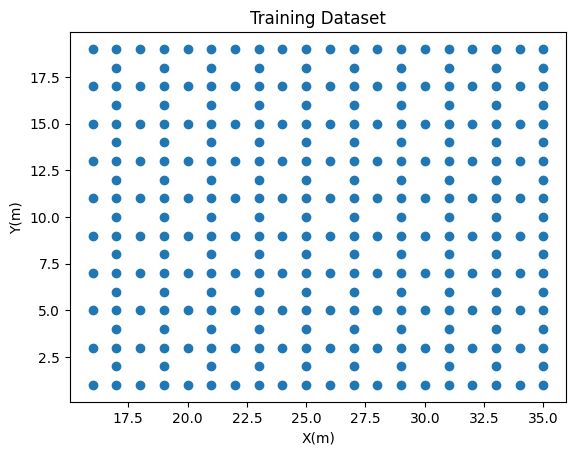

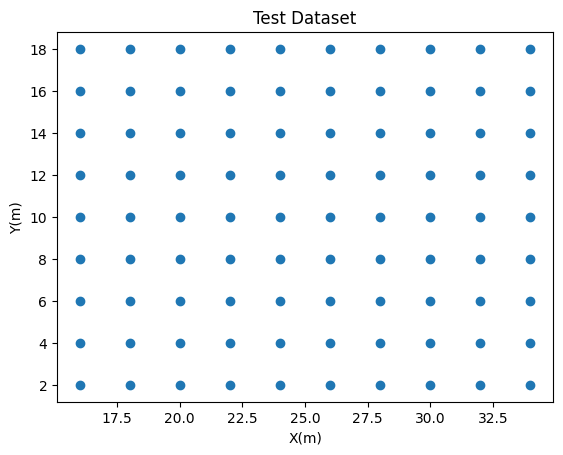

In [59]:
plot_floor_data(training_df, "Training Dataset")
plot_floor_data(test_df, "Test Dataset")

In [60]:
td_model, X_t, Y_t, scaler = train_tdm(training_df, ap_cols=get_ap_columns(training_df), cond_cols=cond_cols, epochs=2000, batch_size=64)

Y_rss.shape: (290, 21)
Device: cuda
[TableDiffusion] Epoch 1/2000 - loss: 0.5065
[TableDiffusion] Epoch 10/2000 - loss: 0.4748
[TableDiffusion] Epoch 20/2000 - loss: 0.5024
[TableDiffusion] Epoch 30/2000 - loss: 0.3808
[TableDiffusion] Epoch 40/2000 - loss: 0.2748
[TableDiffusion] Epoch 50/2000 - loss: 0.1962
[TableDiffusion] Epoch 60/2000 - loss: 0.1758
[TableDiffusion] Epoch 70/2000 - loss: 0.1685
[TableDiffusion] Epoch 80/2000 - loss: 0.1665
[TableDiffusion] Epoch 90/2000 - loss: 0.1614
[TableDiffusion] Epoch 100/2000 - loss: 0.1549
[TableDiffusion] Epoch 110/2000 - loss: 0.1520
[TableDiffusion] Epoch 120/2000 - loss: 0.1446
[TableDiffusion] Epoch 130/2000 - loss: 0.1369
[TableDiffusion] Epoch 140/2000 - loss: 0.1415
[TableDiffusion] Epoch 150/2000 - loss: 0.1363
[TableDiffusion] Epoch 160/2000 - loss: 0.1326
[TableDiffusion] Epoch 170/2000 - loss: 0.1341
[TableDiffusion] Epoch 180/2000 - loss: 0.1284
[TableDiffusion] Epoch 190/2000 - loss: 0.1267
[TableDiffusion] Epoch 200/2000 - l

In [61]:
synthetic_df = generate_synthetic_rss(td_model=td_model, scaler=scaler, coordinates=test_df[cond_cols])

Device: cuda
torch.Size([90, 2])


### KNN Evaluation

In [62]:
X_ap_train = training_df[get_ap_columns(training_df)].fillna(-110).values
y_xy_train = training_df[cond_cols].values

X_ap_test = test_df[get_ap_columns(test_df)].fillna(-110).values
y_xy_test = test_df[cond_cols].values

X_ap_synth = synthetic_df[get_ap_columns(synthetic_df)].fillna(-110).values
y_xy_synth = synthetic_df[cond_cols].values

In [63]:
from sklearn.model_selection import GridSearchCV

knn_scaler=StandardScaler()
X_ap_train_scaled = knn_scaler.fit_transform(X_ap_train)

# KNN multi-output
knn = KNeighborsRegressor(
    weights='distance',  # closer fingerprints count more
    metric='euclidean')

param_grid = {'n_neighbors': range(3, 31)}
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_search.fit(X_ap_train_scaled, y_xy_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_}")

knn_best = grid_search.best_estimator_

pred_locations_synth = knn_best.predict(knn_scaler.transform(X_ap_synth))

Best parameters: {'n_neighbors': 3}
Best score: -2.6075663684499073


In [64]:
np.mean(compute_localization_errors(y_xy_test, pred_locations_synth))

np.float64(1.07457687597158)

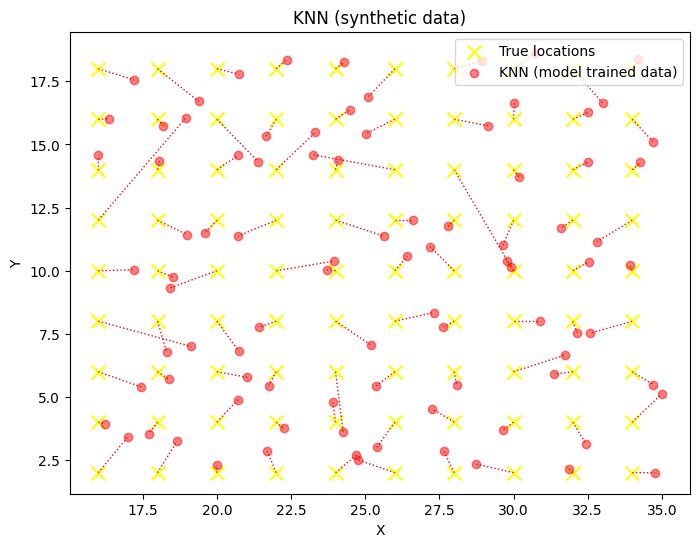

In [65]:
plot_indoor_localization_results(y_xy_test, pred_locations_synth, "KNN (synthetic data)")

In [66]:
X_combined = pd.concat([pd.DataFrame(X_ap_train), pd.DataFrame(X_ap_synth)], axis=0).values
y_combined = pd.concat([pd.DataFrame(y_xy_train), pd.DataFrame(y_xy_synth)], axis=0).values

In [67]:
from sklearn.model_selection import GridSearchCV

knn_scaler=StandardScaler()
X_combined_scaled = knn_scaler.fit_transform(X_combined)

# KNN multi-output
knn = KNeighborsRegressor(
    weights='distance',  # closer fingerprints count more
    metric='euclidean')

param_grid = {'n_neighbors': range(3, 31)}
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_search.fit(X_combined_scaled, y_combined)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_}")

knn_best = grid_search.best_estimator_

pred_locations_test = knn_best.predict(knn_scaler.transform(X_ap_test))

Best parameters: {'n_neighbors': 3}
Best score: -1.2682789309080158


In [68]:
np.mean(compute_localization_errors(y_xy_test, pred_locations_test))

np.float64(1.8562834584818262)

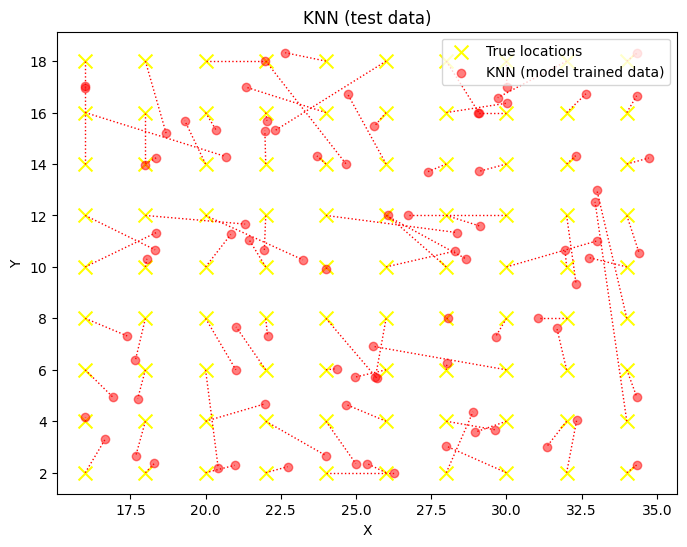

In [69]:
plot_indoor_localization_results(y_xy_test, pred_locations_test, "KNN (test data)")